In [1]:
# This file is a jupytext-paired Python script export of
# `building_decision_models_solution.ipynb`. The canonical artifact for learners
# is the notebook (.ipynb); this script is provided for code review and
# `git diff` readability. Run `jupytext --sync` to keep the two in lockstep
# after edits.

# Building and Solving Decision Models Programmatically (SOLUTION)

## Scenario

You are the lead decision scientist at **StrideWear**, a fictional athletic
apparel brand preparing to launch a new performance running shoe next season.
The launch commitment must be made 12 months in advance. Three go-to-market
options are on the table:

- **Full Launch** — broad multi-channel distribution with a $600K marketing
  spend. High upside if athletic footwear retail demand is strong, meaningful
  loss if demand is weak.
- **Regional Launch** — selective two-region rollout, $200K marketing.
  Moderate upside, limited downside.
- **Hold** — delay the launch one full season. Zero incremental cost or gain.

The decision must be committed now; how well it performs depends on a demand
environment StrideWear can estimate but not control. To characterize that
distribution, the team uses 10 years of monthly US sporting goods store
sales data (FRED MRTSSM45111USS) as a benchmark for what Low, Base, and High
demand conditions look like historically. The data is not StrideWear's own
sales; it is a reference distribution for the retail demand category.

## What this notebook delivers

The Head of Strategy has asked for a decision model — expected value, minimax
regret, and a decision tree visualization — plus a defended choice of rule.
A stakeholder-facing recommendation will be assembled separately; today's
deliverable is the model output and the analytical stance.

## Setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = "../building-decision-models-starter/data/sporting_goods_sales.csv"

# Module-level constants — payoff matrix values ($M incremental profit vs Hold)
PAYOFF_FULL_LOW        = -7.0
PAYOFF_FULL_BASE       =  4.0
PAYOFF_FULL_HIGH       = 12.0
PAYOFF_REGIONAL_LOW    = -0.5
PAYOFF_REGIONAL_BASE   =  2.0
PAYOFF_REGIONAL_HIGH   =  5.5

## 1. Load and inspect the data

In [3]:
sales = pd.read_csv(DATA_PATH, parse_dates=["DATE"], index_col="DATE")
display(sales.head())
display(sales.tail())
print(f"\nTotal rows: {len(sales)}")

,MRTSSM45111USS
DATE,
2015-01-01,4150
2015-02-01,4180
2015-03-01,4220
2015-04-01,4190
2015-05-01,4260


,MRTSSM45111USS
DATE,
2024-08-01,5720
2024-09-01,5760
2024-10-01,5730
2024-11-01,5700
2024-12-01,5780



Total rows: 120


## 2. Compute year-over-year growth rates

A 12-period percentage change gives the year-over-year growth rate for each
month. The first 12 rows will be NaN — drop them before binning.

In [4]:
sales["yoy"] = sales["MRTSSM45111USS"].pct_change(12) * 100
sales = sales.dropna(subset=["yoy"])

print(f"Months with YoY data: {len(sales)}")
print(f"YoY range: {sales['yoy'].min():.2f}% to {sales['yoy'].max():.2f}%")
display(sales[["MRTSSM45111USS", "yoy"]].head(6))

Months with YoY data: 108
YoY range: -40.43% to 101.79%


,MRTSSM45111USS,yoy
DATE,,
2016-01-01,4330,4.337349
2016-02-01,4280,2.392344
2016-03-01,4350,3.080569
2016-04-01,4310,2.863962
2016-05-01,4390,3.051643
2016-06-01,4420,2.552204


## 3. Classify each month into a demand state

Tertile binning: the 33rd percentile separates Low from Base; the 67th
percentile separates Base from High. Because the bins are constructed to
each capture one-third of the historical months, the three states are
equally probable by construction.

In [5]:
Q33 = sales["yoy"].quantile(1 / 3)
Q67 = sales["yoy"].quantile(2 / 3)

print(f"33rd-percentile cut (Low | Base): {Q33:.2f}%")
print(f"67th-percentile cut (Base | High): {Q67:.2f}%")

sales["state"] = pd.cut(
    sales["yoy"],
    bins=[-np.inf, Q33, Q67, np.inf],
    labels=["Low", "Base", "High"],
)

display(sales[["MRTSSM45111USS", "yoy", "state"]].tail(12))

33rd-percentile cut (Low | Base): 1.07%
67th-percentile cut (Base | High): 3.11%


,MRTSSM45111USS,yoy,state
DATE,,,
2024-01-01,5680,1.067616,Low
2024-02-01,5640,1.075269,Base
2024-03-01,5710,1.061947,Low
2024-04-01,5670,1.069519,Base
2024-05-01,5740,1.056338,Low
2024-06-01,5780,1.048951,Low
2024-07-01,5750,1.054482,Low
2024-08-01,5720,1.060071,Low
2024-09-01,5760,1.052632,Low


The tertile cut-points tell StrideWear what "Low demand" means in concrete
numbers: any 12-month period where YoY sales growth came in below **{Q33:.2f}%**.
A Base environment sits between that floor and **{Q67:.2f}%** growth; High
demand is anything above that ceiling.

## 4. Demand-state probabilities

By construction, each tertile bin contains roughly one-third of the 108
historical months. We use the exact fraction 1/3 for clean arithmetic
downstream. The empirical counts confirm the construction is working.

In [6]:
p = pd.Series({"Low": 1 / 3, "Base": 1 / 3, "High": 1 / 3})

print("Demand-state probability vector:")
print(p.round(4))
print(f"Sum: {p.sum():.4f}")

counts = sales["state"].value_counts().sort_index()
print("\nEmpirical counts per state (should be ~36 each):")
print(counts)

Demand-state probability vector:
Low     0.3333
Base    0.3333
High    0.3333
dtype: float64
Sum: 1.0000

Empirical counts per state (should be ~36 each):
state
Low     36
Base    37
High    35
Name: count, dtype: int64


## 5. Payoff matrix

Twelve-month incremental contribution profit ($M) relative to Hold = 0.
Values come from the module-level constants defined in Setup so that
they are easy to audit and change in one place.

In [7]:
payoffs = pd.DataFrame(
    {
        "Low": {
            "Full Launch":     PAYOFF_FULL_LOW,
            "Regional Launch": PAYOFF_REGIONAL_LOW,
            "Hold":            0.0,
        },
        "Base": {
            "Full Launch":     PAYOFF_FULL_BASE,
            "Regional Launch": PAYOFF_REGIONAL_BASE,
            "Hold":            0.0,
        },
        "High": {
            "Full Launch":     PAYOFF_FULL_HIGH,
            "Regional Launch": PAYOFF_REGIONAL_HIGH,
            "Hold":            0.0,
        },
    }
)

print("Payoff matrix ($M incremental profit vs Hold):")
display(payoffs)

Payoff matrix ($M incremental profit vs Hold):


,Low,Base,High
Full Launch,-7.0,4.0,12.0
Regional Launch,-0.5,2.0,5.5
Hold,0.0,0.0,0.0


## 6. Expected value per option

`(payoffs * p).sum(axis=1)` broadcasts the probability Series across the
columns of the payoff DataFrame, multiplies each state's payoff by its
probability, and sums across states for each option.

In [8]:
ev = (payoffs * p).sum(axis=1)

print("Expected value per option ($M):")
display(ev.round(3).to_frame("EV ($M)"))
print(f"\nEV-maximizing option: {ev.idxmax()}  (EV = ${ev.max():.2f}M)")

Expected value per option ($M):


,EV ($M)
Full Launch,3.000
Regional Launch,2.333
Hold,0.000



EV-maximizing option: Full Launch  (EV = $3.00M)


## 7. Minimax regret per option

For each demand state, the *regret* of an option is the gap between the best
available payoff in that state and the payoff this option delivers. Minimax
regret selects the option whose worst-case regret is smallest — a conservative
criterion that guards against the largest possible "I should have chosen
differently" feeling.

In [9]:
best_per_state = payoffs.max(axis=0)          # best payoff in each state
regret = best_per_state - payoffs             # regret matrix
max_regret = regret.max(axis=1)              # worst-case regret per option

print("Regret matrix ($M — how much you'd wish you'd done something else):")
display(regret)

print("\nMax regret per option ($M):")
display(max_regret.round(3).to_frame("Max regret ($M)"))

print(f"\nMinimax-regret option: {max_regret.idxmin()}  "
      f"(max regret = ${max_regret.min():.2f}M)")

Regret matrix ($M — how much you'd wish you'd done something else):


,Low,Base,High
Full Launch,7.0,0.0,0.0
Regional Launch,0.5,2.0,6.5
Hold,0.0,4.0,12.0



Max regret per option ($M):


,Max regret ($M)
Full Launch,7.0
Regional Launch,6.5
Hold,12.0



Minimax-regret option: Regional Launch  (max regret = $6.50M)


## 8. Decision tree visualization

The tree makes the structure legible at a glance: one root decision node,
three option branches, three demand-state leaves per branch, each leaf
labeled with the payoff.

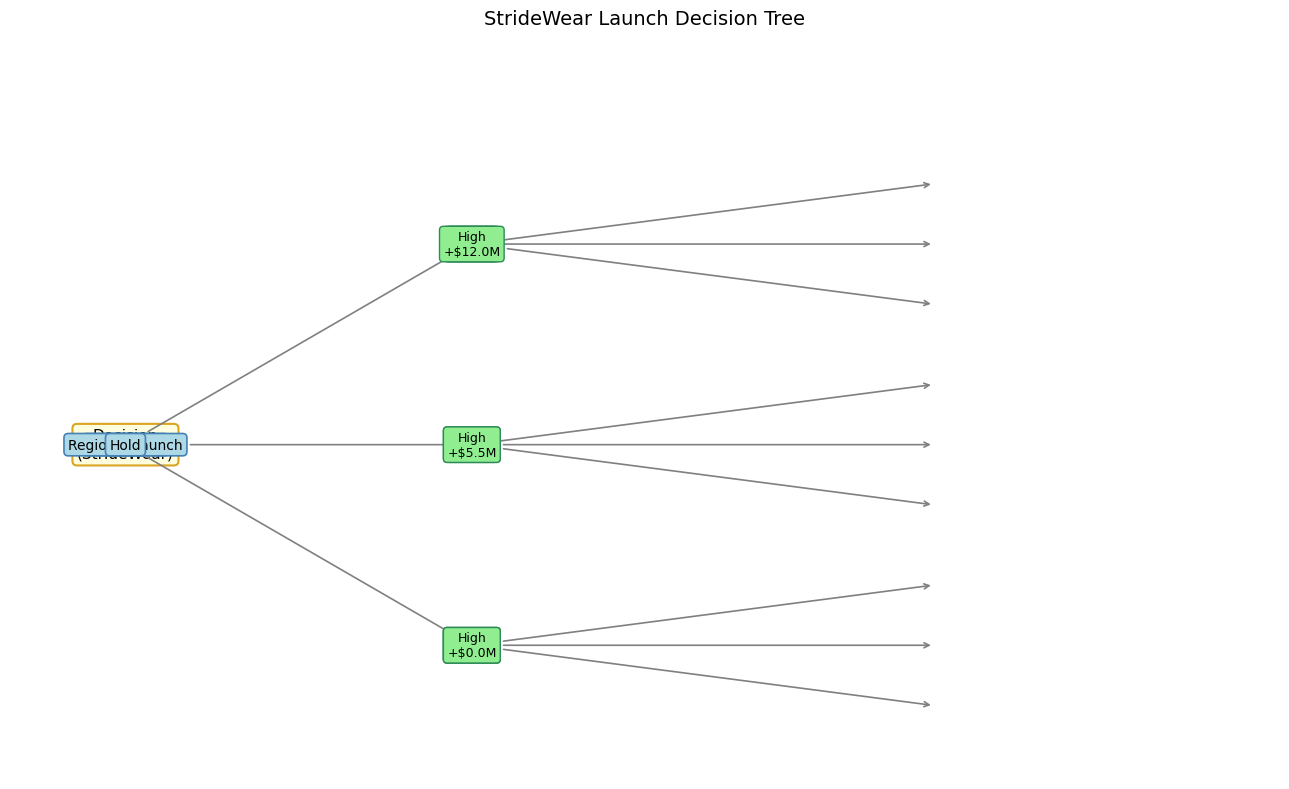

In [10]:
OPTIONS = list(payoffs.index)
STATES = list(payoffs.columns)

# Layout parameters
ROOT_X,   ROOT_Y   = 1.0, 5.0
OPTION_X            = 4.0
LEAF_X              = 8.0
OPTION_Y_POSITIONS  = [8.0, 5.0, 2.0]        # y-centres for each option branch
STATE_Y_OFFSETS     = [0.9, 0.0, -0.9]       # y-spread of leaf nodes per option

NODE_STYLE_ROOT   = dict(boxstyle="round", fc="lightyellow", ec="goldenrod", lw=1.5)
NODE_STYLE_OPTION = dict(boxstyle="round", fc="lightblue",   ec="steelblue",  lw=1.2)
NODE_STYLE_LEAF   = dict(boxstyle="round", fc="lightgreen",  ec="seagreen",   lw=1.0)
ARROW_STYLE = dict(arrowstyle="->", color="gray", lw=1.2)

fig, ax = plt.subplots(figsize=(13, 8))
ax.axis("off")
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)

# Root node
ax.annotate(
    "Decision\n(StrideWear)",
    xy=(ROOT_X, ROOT_Y),
    fontsize=11, ha="center", va="center",
    bbox=NODE_STYLE_ROOT,
)

for opt, opt_y in zip(OPTIONS, OPTION_Y_POSITIONS):
    # Draw option branch node
    ax.annotate(
        opt,
        xy=(OPTION_X, opt_y),
        fontsize=10, ha="center", va="center",
        bbox=NODE_STYLE_OPTION,
        arrowprops=ARROW_STYLE,
        xytext=(ROOT_X, ROOT_Y),
    )

    for state, dy in zip(STATES, STATE_Y_OFFSETS):
        payoff_val = payoffs.loc[opt, state]
        leaf_y = opt_y + dy
        sign = "+" if payoff_val >= 0 else ""
        label = f"{state}\n{sign}${payoff_val:.1f}M"
        ax.annotate(
            label,
            xy=(LEAF_X, leaf_y),
            fontsize=9, ha="center", va="center",
            bbox=NODE_STYLE_LEAF,
            arrowprops=ARROW_STYLE,
            xytext=(OPTION_X, opt_y),
        )

ax.set_title("StrideWear Launch Decision Tree", fontsize=14, pad=14)
plt.tight_layout()
plt.show()

## 9. Compare the decision rules

In [11]:
comparison = pd.DataFrame(
    {
        "Selected option": [ev.idxmax(), max_regret.idxmin()],
        "Score": [
            f"EV = ${ev.max():.2f}M",
            f"Max regret = ${max_regret.min():.2f}M",
        ],
    },
    index=["EV-max", "Minimax regret"],
)
display(comparison)

,Selected option,Score
EV-max,Full Launch,EV = $3.00M
Minimax regret,Regional Launch,Max regret = $6.50M


**The two rules disagree.** EV-max selects **Full Launch** ($3.0M expected
profit), while minimax regret selects **Regional Launch** (worst-case regret
$6.5M vs Full Launch's $7.0M).

The disagreement is real and driven by Full Launch's −$7.0M payoff in a Low
demand environment. Full Launch has the highest expected profit because the
$12.0M High-demand upside outweighs the downside on average. But a
risk-conservative analyst who wants to cap the worst-case "I should have
chosen differently" outcome would prefer Regional Launch, whose $6.5M maximum
regret is just below Full Launch's $7.0M.

**The decision rule I would lean on is EV-max.** With equal 1/3 probabilities
across states and a $1.0M gap in expected profit, Full Launch is the
analytically stronger choice for a firm that will face many such decisions
over time. A firm more concerned with downside protection — or one where a
$7M loss in a single season would be existential — would reasonably prefer
minimax regret and Regional Launch instead.

This deliverable stops at the defended-rule level. Translating the comparison
into a stakeholder-facing recommendation requires additional context —
balance-sheet capacity, portfolio effects, strategic alternatives — that is
addressed in separate modules.

## 10. Sensitivity flex — pessimistic demand weights

The baseline probabilities assume equal 1/3 weight on each state. What if
the team believes the next 12 months are more likely to be weak than the
historical base rate suggests? Under P(Low) = 0.5, P(Base) = 0.3,
P(High) = 0.2, does the EV-max option change?

In [12]:
p_pess = pd.Series({"Low": 0.5, "Base": 0.3, "High": 0.2})

ev_pess = (payoffs * p_pess).sum(axis=1)

print("EV per option under pessimistic demand weights ($M):")
display(ev_pess.round(3).to_frame("EV pess ($M)"))
print(f"\nEV-max under pessimistic weights: {ev_pess.idxmax()}  "
      f"(${ev_pess.max():.2f}M)")
print(f"EV-max under baseline weights:    {ev.idxmax()}  "
      f"(${ev.max():.2f}M)")

EV per option under pessimistic demand weights ($M):


,EV pess ($M)
Full Launch,0.10
Regional Launch,1.45
Hold,0.00



EV-max under pessimistic weights: Regional Launch  ($1.45M)
EV-max under baseline weights:    Full Launch  ($3.00M)


Under pessimistic weights, Full Launch's EV drops to $0.1M — barely above
zero — while Regional Launch holds at $1.45M. **The EV-max option flips to
Regional Launch.** The baseline Full Launch recommendation is conditional on
the equal 1/3 probability assumption; if the team believes a Low-demand
environment is materially more likely than one-in-three, the expected-profit
case for Full Launch nearly disappears. Any stakeholder-facing recommendation
built on this model should state explicitly which probability assumption it
is conditional on.

---
## Nimbus Streaming — How this exercise prepares Step 6

The Nimbus Streaming capstone project asks you to complete **Step 6: Decision
tree (options × posterior states, backward induction)**. Everything built here
maps directly onto that step:

- The probability vector `p = pd.Series({"Low": 1/3, "Base": 1/3, "High": 1/3})`
  is the same pattern the project uses — derived from tertile-binning a
  posterior distribution rather than historical YoY growth rates, but the
  data structure and indexing convention are identical.
- The payoff matrix `pd.DataFrame` with options as rows and states as columns,
  and the EV formula `(payoffs * p).sum(axis=1)`, carry over without change.
- The minimax regret calculation (`best_per_state - payoffs`, then row-wise
  max) is reused verbatim in the project.
- The matplotlib decision tree visualization with `boxstyle="round"` nodes
  is the same rendering approach the project solution uses.

The project has four options instead of three and derives its payoff values
from Nimbus's cost-benefit model rather than stipulating them. The code
patterns transfer directly.